# PSO Experiments and Stability Analysis

This notebook does:

1. Loads data and baseline models
2. Explicitly iterates through the PSO parameters: n_particles and n_iterations
3. Compares baseline vs optimized models
4. Analyzes the stability of selected features across multiple launches


In [2]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   - -------------------------------------- 3.4/100.2 MB 14.4 MB/s eta 0:00:07
   --- ------------------------------------ 9.2/100.2 MB 21.1 MB/s eta 0:00:05
   ----- ---------------------------------- 12.8/100.2 MB 20.1 MB/s eta 0:00:05
   ------ --------------------------------- 16.5/100.2 MB 18.6 MB/s eta 0:00:05
   -------- ------------------------------- 21.2/100.2 MB 19.2 MB/s eta 0:00:05
   --------- ------------------------------ 24.1/100.2 MB 18.4 MB/s eta 0:00:05
   ---------- ----------------------------- 26.5/100.2 MB 17.7 MB/s eta 0:00:05
   ------------ --------------------------- 32.0/100.2 MB 18.3 MB/s eta 0:00:04
   -------------- ------------------------- 35.4/100.2 MB 18.0 MB/s eta 0:00:04
   ---------------- ----------------------- 41.4/100.2 MB 19.1 MB/s eta 0:00:04
   ------------------- -------------------- 49.5/100.2 MB 20

In [4]:
import sys
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import resample

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(PROJECT_ROOT))

from src.pso_algorithm import PSOFeatureSelector
from src.models import get_models
from src.evaluation import evaluate

DATA_DIR = PROJECT_ROOT / "data" / "processed"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").values.ravel()
y_test = pd.read_csv(DATA_DIR / "y_test.csv").values.ravel()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Positive class ratio in train:", round(y_train.mean(), 4))

Train shape: (315358, 23)
Test shape: (78840, 23)
Positive class ratio in train: 0.1706


## 1. Baseline results

First, we consider the quality of the models based on the full set of features.


In [5]:
models = get_models()

baseline_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate(model, X_test, y_test)
    baseline_rows.append({
        "model": name,
        "accuracy_baseline": metrics["accuracy"],
        "f1_baseline": metrics["f1"],
        "precision_baseline": metrics["precision"],
        "recall_baseline": metrics["recall"],
        "n_features_baseline": X_train.shape[1]
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("f1_baseline", ascending=False)
baseline_df

,model,accuracy_baseline,f1_baseline,precision_baseline,recall_baseline,n_features_baseline
1,random_forest,0.769305,0.498290,0.396106,0.671524,23
2,catboost,0.728551,0.486454,0.359140,0.753606,23
0,logistic_regression,0.722577,0.479857,0.352762,0.750112,23


## 2. PSO experiments

Below is an explicit enumeration of the `n_particles` and `n_iterations` parameters.  
This block is responsible for experiments.


In [7]:
# Explicit evaluation of PSO parameters
param_grid = [
    {"n_particles": n_particles, "n_iterations": n_iterations}
    for n_particles in [15]
    for n_iterations in [15]
]

SAMPLE_SIZE = 20000
PSO_RANDOM_STATE = 42

experiment_rows = []
selected_features_by_config = {}

for params in param_grid:
    print(f"Running PSO: particles={params['n_particles']}, iterations={params['n_iterations']}")

    X_sample, y_sample = resample(
        X_train,
        y_train,
        n_samples=SAMPLE_SIZE,
        random_state=PSO_RANDOM_STATE,
        stratify=y_train
    )

    pso = PSOFeatureSelector(
        n_particles=params["n_particles"],
        n_iterations=params["n_iterations"],
        random_state=PSO_RANDOM_STATE
    )
    pso.fit(X_sample, y_sample)

    selected_features = X_train.columns[pso.best_features_].tolist()
    selected_features_by_config[(params["n_particles"], params["n_iterations"])] = selected_features

    X_train_reduced = X_train[selected_features]
    X_test_reduced = X_test[selected_features]

    for name, model in get_models().items():
        model.fit(X_train_reduced, y_train)
        metrics = evaluate(model, X_test_reduced, y_test)

        experiment_rows.append({
            "n_particles": params["n_particles"],
            "n_iterations": params["n_iterations"],
            "model": name,
            "n_selected": len(selected_features),
            "selected_features": ", ".join(selected_features),
            "accuracy_pso": metrics["accuracy"],
            "f1_pso": metrics["f1"],
            "precision_pso": metrics["precision"],
            "recall_pso": metrics["recall"],
        })

experiments_df = pd.DataFrame(experiment_rows)
experiments_df.head()

Running PSO: particles=15, iterations=15


,n_particles,n_iterations,model,n_selected,selected_features,accuracy_pso,f1_pso,precision_pso,recall_pso
0,15,15,logistic_regression,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.716958,0.471622,0.346003,0.740446
1,15,15,random_forest,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.750254,0.485632,0.374346,0.691078
2,15,15,catboost,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.720358,0.477671,0.350534,0.749517


## 3. Compare optimized models with baseline results

We combine baseline and PSO results into one table and calculate the difference.

In [8]:
comparison_df = experiments_df.merge(baseline_df, on="model", how="left")

comparison_df["delta_accuracy"] = comparison_df["accuracy_pso"] - comparison_df["accuracy_baseline"]
comparison_df["delta_f1"] = comparison_df["f1_pso"] - comparison_df["f1_baseline"]

comparison_df = comparison_df.sort_values(["model", "f1_pso"], ascending=[True, False])
comparison_df

,n_particles,n_iterations,model,n_selected,selected_features,accuracy_pso,f1_pso,precision_pso,recall_pso,accuracy_baseline,f1_baseline,precision_baseline,recall_baseline,n_features_baseline,delta_accuracy,delta_f1
2,15,15,catboost,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.720358,0.477671,0.350534,0.749517,0.728551,0.486454,0.359140,0.753606,23,-0.008194,-0.008783
0,15,15,logistic_regression,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.716958,0.471622,0.346003,0.740446,0.722577,0.479857,0.352762,0.750112,23,-0.005619,-0.008236
1,15,15,random_forest,11,"SEX, AGE, BMI, EMPLOYMENT_STATUS, INCOME_LEVEL...",0.750254,0.485632,0.374346,0.691078,0.769305,0.498290,0.396106,0.671524,23,-0.019051,-0.012658


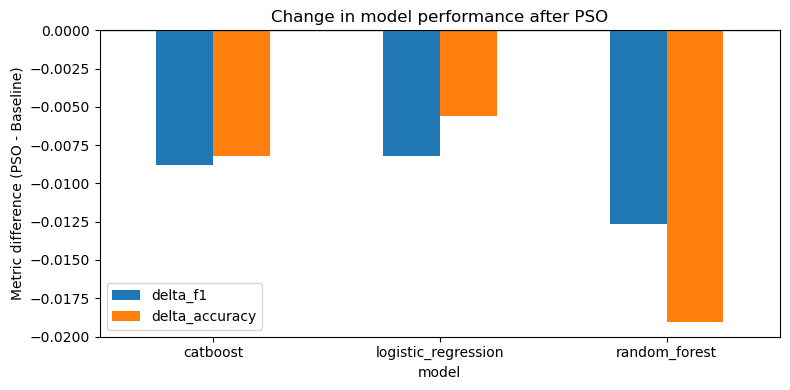

In [9]:
delta_plot_df = (
    comparison_df.sort_values(["model", "f1_pso"], ascending=[True, False])
    .groupby("model", as_index=False)
    .first()[["model", "delta_f1", "delta_accuracy"]]
    .set_index("model")
)

ax = delta_plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Change in model performance after PSO")
ax.set_ylabel("Metric difference (PSO - Baseline)")
ax.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_vs_pso_delta.png", dpi=200)
plt.show()

### We can see that pso slightly degrades accuracy

### Choosing the best parameters for each model

In [10]:
best_configs_df = (
    comparison_df.sort_values("f1_pso", ascending=False)
    .groupby("model", as_index=False)
    .first()[[
        "model",
        "n_particles",
        "n_iterations",
        "n_selected",
        "accuracy_baseline",
        "accuracy_pso",
        "delta_accuracy",
        "f1_baseline",
        "f1_pso",
        "delta_f1"
    ]]
)
best_configs_df

,model,n_particles,n_iterations,n_selected,accuracy_baseline,accuracy_pso,delta_accuracy,f1_baseline,f1_pso,delta_f1
0,catboost,15,15,11,0.728551,0.720358,-0.008194,0.486454,0.477671,-0.008783
1,logistic_regression,15,15,11,0.722577,0.716958,-0.005619,0.479857,0.471622,-0.008236
2,random_forest,15,15,11,0.769305,0.750254,-0.019051,0.498290,0.485632,-0.012658


## 4. Main comparison plots


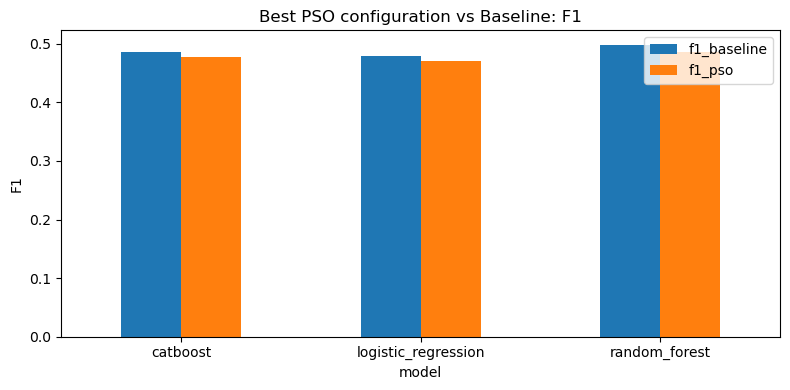

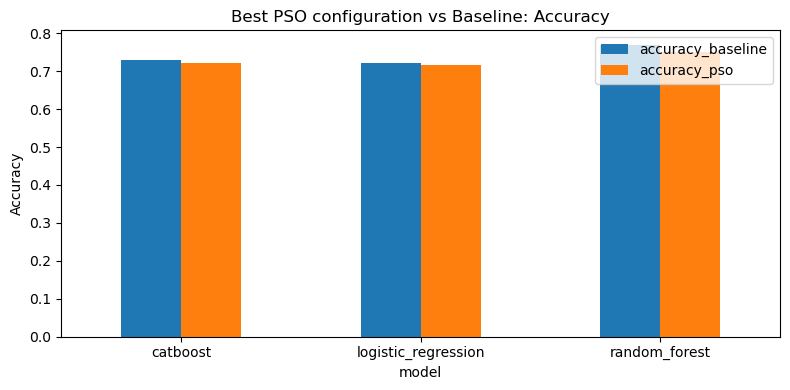

In [11]:
plot_df = best_configs_df.set_index("model")[["f1_baseline", "f1_pso"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Best PSO configuration vs Baseline: F1")
ax.set_ylabel("F1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_vs_pso_f1.png", dpi=200)
plt.show()

plot_df = best_configs_df.set_index("model")[["accuracy_baseline", "accuracy_pso"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Best PSO configuration vs Baseline: Accuracy")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_vs_pso_accuracy.png", dpi=200)
plt.show()

## 5. Stability analysis

We take **one best PSO configuration** and run it several times with different `random_state'.


In [14]:
# Choosing the best configuration based on the avg F1 score after applying PSO
config_scores = (
    comparison_df.groupby(["n_particles", "n_iterations"], as_index=False)["f1_pso"]
    .mean()
    .sort_values("f1_pso", ascending=False)
)

best_particles = int(config_scores.iloc[0]["n_particles"])
best_iterations = int(config_scores.iloc[0]["n_iterations"])

print("Best config for stability:")
print("n_particles =", best_particles)
print("n_iterations =", best_iterations)
SEEDS = [7] # Simple for presentation
# SEEDS = [42, 123, 7, 99, 2026, 100, 400] 
stability_runs = []

for seed in SEEDS:
    X_sample, y_sample = resample(
        X_train,
        y_train,
        n_samples=SAMPLE_SIZE,
        random_state=seed,
        stratify=y_train
    )

    pso = PSOFeatureSelector(
        n_particles=best_particles,
        n_iterations=best_iterations,
        random_state=seed
    )
    pso.fit(X_sample, y_sample)

    selected_features = X_train.columns[pso.best_features_].tolist()

    stability_runs.append({
        "seed": seed,
        "n_selected": len(selected_features),
        "selected_features": selected_features
    })

Best config for stability:
n_particles = 15
n_iterations = 15


In [15]:
# The frequency of feature selection
all_features = []
for run in stability_runs:
    all_features.extend(run["selected_features"])

stability_df = (
    pd.Series(all_features)
    .value_counts()
    .rename_axis("feature")
    .reset_index(name="selected_count")
)
stability_df["selected_ratio"] = stability_df["selected_count"] / len(SEEDS)
stability_df = stability_df.sort_values(["selected_count", "feature"], ascending=[False, True])

stability_df

,feature,selected_count,selected_ratio
1,BMI,1,1.0
9,CHOL_MEDS,1,1.0
2,EMPLOYMENT_STATUS,1,1.0
4,GEN_HLTH,1,1.0
0,HGHT (ft),1,1.0
7,HIGH_BP,1,1.0
8,HIGH_CHOL,1,1.0
3,INSR_STATUS,1,1.0
6,MENT_HLTH_DAYS,1,1.0
5,PHYS_HLTH_DAYS,1,1.0


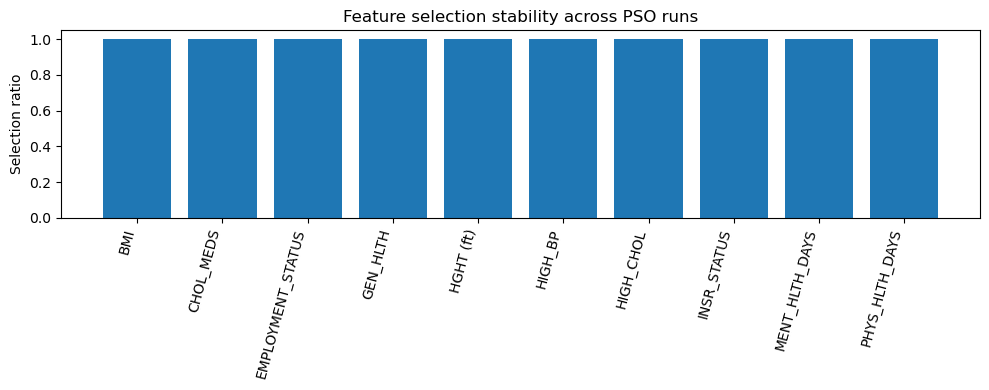

In [16]:
# Bar chart of feature stability
top_df = stability_df.copy()
plt.figure(figsize=(10, 4))
plt.bar(top_df["feature"], top_df["selected_ratio"])
plt.title("Feature selection stability across PSO runs")
plt.ylabel("Selection ratio")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pso_feature_stability_bar.png", dpi=200)
plt.show()

## 6. Save results


In [17]:
baseline_df.to_csv(METRICS_DIR / "baseline_results.csv", index=False)
experiments_df.to_csv(METRICS_DIR / "pso_experiments.csv", index=False)
comparison_df.to_csv(METRICS_DIR / "baseline_vs_pso_comparison.csv", index=False)
best_configs_df.to_csv(METRICS_DIR / "best_pso_configs_by_model.csv", index=False)
stability_df.to_csv(METRICS_DIR / "pso_stability.csv", index=False)

print("Saved CSV files to:", METRICS_DIR)
print("Saved figures to:", FIGURES_DIR)

Saved CSV files to: C:\Users\Honor\Swarm-optimization-in-medicine\results\metrics
Saved figures to: C:\Users\Honor\Swarm-optimization-in-medicine\results\figures


## 7. What this notebook gives you

- `baseline_results.csv` — baseline metrics  
- `pso_experiments.csv` — all experiments with iterating over `n_particles` and `n_iterations` 
- `baseline_vs_pso_comparison.csv` — baseline vs optimized comparison
- `best_pso_configs_by_model.csv` — the best PSO configuration for each model  
- `pso_stability.csv` — frequency of feature selection  

Images:
- `baseline_vs_pso_f1.png`
- `baseline_vs_pso_accuracy.png`
- `pso_feature_stability_bar.png`